# Caden Darby - Urban Transit Analysis


---
---
# Analyzing correlation between mode of transit and average daily commute time for Americans
---
---

***
## Data Description and Source
* The datasets I selected came from the USDOT and contain just over 85,000 rows and 32 columns. The data was mostly clean and free from error. One dataset focused on average commute time to work for americans categorized into bins, including both totals and percentages. The second dataset contained the most common methods of transport for americans, again categorized in both percentages and totals.
* Data Attribution: Both datasets came from the United States Department of Transportaion 1. https://geodata.bts.gov/datasets/usdot::means-of-transportation-to-work/explore?location=1.427876%2C0.314298%2C1.75&showTable=true,  2. https://geodata.bts.gov/datasets/usdot::travel-time-to-work/about

***
## Research Question
* How do Americans choice of transportation affect their daily commute time?.


***
## Import Libraries and Set Preferences for Visualization

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

***
## Read and Verify Data


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
transport_df = pd.read_csv('/content/drive/MyDrive/NTAD_Means_of_Transportation_to_Work_6734856407395071259.csv')
time_df = pd.read_csv('/content/drive/MyDrive/NTAD_Travel_Time_to_Work_4440510646738068379.csv')

Mounted at /content/drive


***
## Analyses and Visualizations



In [ ]:
# enter and test your code here
# Columns to be used in the transport_df
transport_columns = [
    'NAME',
    'Total workers',
    'Workers traveling by car, truck, or van',
    'Workers traveling by car, truck, or van - drove alone',
    'Workers traveling by car, truck, or van - carpooled',
    'Workers traveling by public transportation',
    'Workers traveling by bicycle',
    'Workers traveling by walking',
    'Workers traveling by other means',
    'Workers working from home',
    '% of workers traveling by car, truck, or van',
    '% of workers traveling by car, truck, or van - drove alone',
    '% of workers traveling by car, truck, or van - carpooled',
    '% of workers traveling by public transportation',
    '% of workers traveling by bicycle',
    '% of workers traveling by walking',
    '% of workers traveling by other means',
    '% of workers working from home']

# DataFrame containing all trasport method columns
transport_df = transport_df.loc[:,transport_columns]

# Columns for time_df
time_columns = [
    'NAME',
    'Total workers',
    'Workers with commute of 0 to 9 minutes',
    'Workers with commute of 10 to 19 minutes',
    'Workers with commute of 20 to 29 minutes',
    'Workers with commute of 30 to 44 minutes',
    'Workers with commute of 45 to 59 minutes',
    'Workers with commute of 60 to 89 minutes',
    'Workers with commute of 90 or more minutes',
    '% of workers with commute of 0 to 9 minutes',
    '% of workers with commute of 10 to 19 minutes',
    '% of workers with commute of 20 to 29 minutes',
    '% of workers with commute of 30 to 44 minutes',
    '% of workers with commute of 45 to 59 minutes',
    '% of workers with commute of 60 to 89 minutes',
    '% of workers with commute of 90 or more minutes']

# DataFrame containing all commute time columns
time_df = time_df.loc[:, time_columns]

# Merge transport and time DataFrames on the shared 'NAME' column to create a new DataFrame
transport_time_df = pd.merge(transport_df, time_df, on='NAME')

# Drop NA Values
transport_time_df = transport_time_df.dropna()

# Generate descriptive statitics
transport_time_df.describe()

,Total workers_x,"Workers traveling by car, truck, or van","Workers traveling by car, truck, or van - drove alone","Workers traveling by car, truck, or van - carpooled",Workers traveling by public transportation,Workers traveling by bicycle,Workers traveling by walking,Workers traveling by other means,Workers working from home,"% of workers traveling by car, truck, or van",...,Workers with commute of 45 to 59 minutes,Workers with commute of 60 to 89 minutes,Workers with commute of 90 or more minutes,% of workers with commute of 0 to 9 minutes,% of workers with commute of 10 to 19 minutes,% of workers with commute of 20 to 29 minutes,% of workers with commute of 30 to 44 minutes,% of workers with commute of 45 to 59 minutes,% of workers with commute of 60 to 89 minutes,% of workers with commute of 90 or more minutes
count,84385.000000,84385.000000,84385.000000,84385.000000,84385.000000,84385.000000,84385.000000,84385.000000,84385.000000,84385.000000,...,84385.000000,84385.000000,84385.000000,84385.000000,84385.000000,84385.000000,84385.000000,84385.000000,84385.000000,84385.000000
mean,1869.467382,1500.840683,1341.323209,159.517473,70.595769,8.579179,45.430894,26.359756,217.661101,80.591163,...,134.386988,100.379226,46.462819,13.227598,28.768498,20.710787,20.394393,7.966515,6.051307,2.880924
std,910.829512,775.495718,704.444664,132.156552,196.848244,28.504807,116.810239,42.953144,215.324192,15.880168,...,132.008541,115.794580,61.777964,10.957405,12.668856,9.503308,10.168185,6.319539,6.123641,3.560141
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1214.000000,943.000000,834.000000,68.000000,0.000000,0.000000,0.000000,0.000000,69.000000,76.010000,...,42.000000,23.000000,7.000000,5.810000,19.640000,14.010000,12.920000,3.180000,1.700000,0.510000
50%,1756.000000,1414.000000,1261.000000,128.000000,6.000000,0.000000,16.000000,12.000000,153.000000,84.920000,...,98.000000,63.000000,27.000000,10.420000,27.430000,20.130000,19.910000,6.660000,4.290000,1.820000
75%,2391.000000,1958.000000,1756.000000,215.000000,53.000000,0.000000,48.000000,35.000000,297.000000,90.670000,...,187.000000,137.000000,62.000000,17.330000,36.790000,26.710000,27.000000,11.300000,8.560000,3.930000
max,25857.000000,14622.000000,10800.000000,5378.000000,4296.000000,1442.000000,9426.000000,1453.000000,2950.000000,100.000000,...,2465.000000,2191.000000,1168.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,71.930000


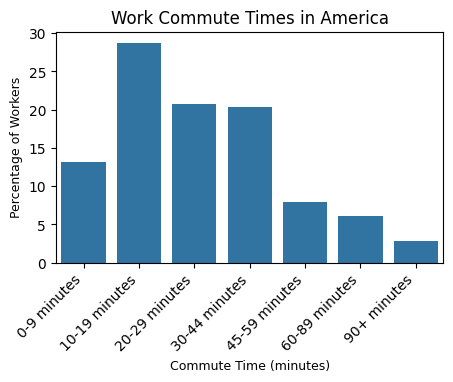

In [ ]:
# Define columns to be used in the visualization
time_columns = [
    '% of workers with commute of 0 to 9 minutes',
    '% of workers with commute of 10 to 19 minutes',
    '% of workers with commute of 20 to 29 minutes',
    '% of workers with commute of 30 to 44 minutes',
    '% of workers with commute of 45 to 59 minutes',
    '% of workers with commute of 60 to 89 minutes',
    '% of workers with commute of 90 or more minutes']

# Plotting bar graph
plt.figure(figsize=(5, 3))
sns.barplot(data=transport_time_df.loc[:,time_columns].mean())
plt.title('Work Commute Times in America', fontsize=12)
plt.ylabel('Percentage of Workers', fontsize=9)
plt.xlabel('Commute Time (minutes)', fontsize=9)

# Create new labels for x axis values in order to fit them into the visualization
new_labels = ['0-9 minutes', '10-19 minutes', '20-29 minutes',
              '30-44 minutes', '45-59 minutes', '60-89 minutes',
              '90+ minutes']

# Adjust x-axis labels and set the new labels
plt.xticks(ticks=range(len(time_columns)), labels=new_labels,ha='right', rotation=45)

plt.show()

<ipython-input-13-36a9a044ea3b>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=transport_time_df.loc[:,transport_method_columns].mean().sort_values(ascending=False),palette='Set2')


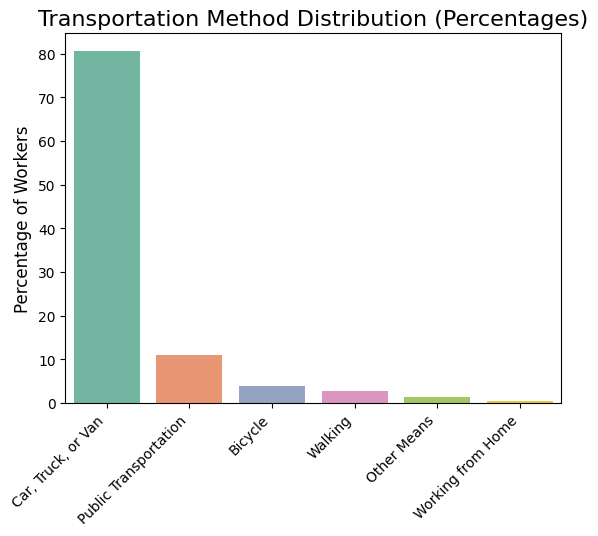

In [ ]:
# Define columns to be used in the visualization
transport_method_columns = [
    '% of workers traveling by car, truck, or van',
    '% of workers traveling by public transportation',
    '% of workers traveling by bicycle',
    '% of workers traveling by walking',
    '% of workers traveling by other means',
    '% of workers working from home']

# Create bar chart
sns.barplot(data=transport_time_df.loc[:,transport_method_columns].mean().sort_values(ascending=False),palette='Set2')

plt.title('Transportation Method Distribution (Percentages)', fontsize=16)
plt.ylabel('Percentage of Workers', fontsize=12)

# Define new shorter labels for transportation methods to fit on the plot
new_labels = [
    'Car, Truck, or Van',
    'Public Transportation',
    'Bicycle',
    'Walking',
    'Other Means',
    'Working from Home']

# Adjust x-axis labels and set new labels
plt.xticks(ticks=range(len(transport_method_columns)), labels=new_labels, rotation=45,ha='right', fontsize=10)

plt.show()

Drove Alone: 89.22
Carpooled: 10.78


<ipython-input-12-89f5115e8078>:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=transport_method_data.index, x=transport_method_data.values, palette="pastel")


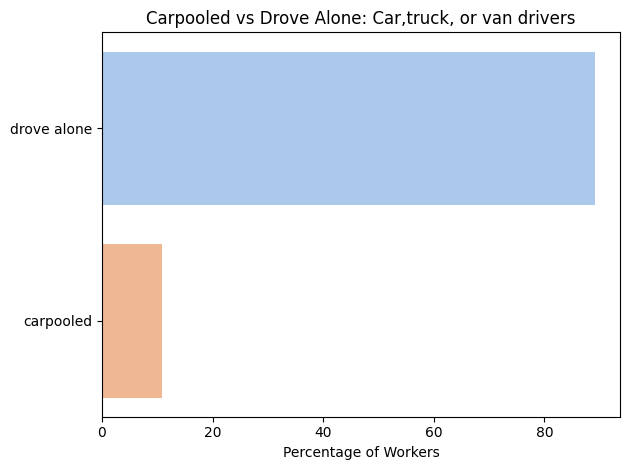

In [ ]:
# Select colums to use in the visualization
new_transport_method_columns = ['% of workers traveling by car, truck, or van - drove alone',
                            '% of workers traveling by car, truck, or van - carpooled']

# Calculate the sum of workers traveling by car, truck, or van
total_car_truck_van = transport_time_df['% of workers traveling by car, truck, or van'].mean()

# Calculate the percentage out of those who travel by car, truck, or van
car_truck_van_drove_alone = transport_time_df.loc[:,new_transport_method_columns[0]].mean()
car_truck_van_carpooled = transport_time_df.loc[:,new_transport_method_columns[1]].mean()

# Calculate percentage of car riders who drove alone and carpooled
drove_alone_percentage = (car_truck_van_drove_alone / total_car_truck_van) * 100
carpooled_percentage = (car_truck_van_carpooled / total_car_truck_van) * 100

# Print percentage of car riders that carpooled and drove alone
print(f'Drove Alone: {drove_alone_percentage.round(2)}')
print(f'Carpooled: {carpooled_percentage.round(2)}')

# Create a new Series to plot the adjusted percentages
transport_method_data = pd.Series([drove_alone_percentage, carpooled_percentage],
                                  index=['drove alone', 'carpooled'])

# Create the inverted barplot
sns.barplot(y=transport_method_data.index, x=transport_method_data.values, palette="pastel")

plt.title('Carpooled vs Drove Alone: Car,truck, or van drivers', fontsize=12)
plt.xlabel('Percentage of Workers', fontsize=10)
plt.ylabel('')
plt.tight_layout()
plt.show()

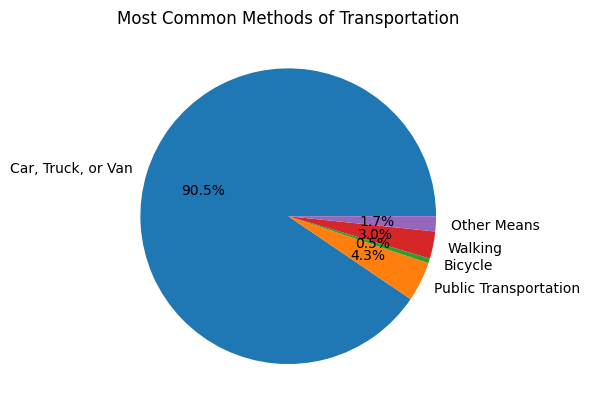

In [ ]:
# Select columns to use
transport_time_df.columns = transport_time_df.columns.str.strip()
transport_method_columns = [
    '% of workers traveling by car, truck, or van',
    '% of workers traveling by public transportation',
    '% of workers traveling by bicycle',
    '% of workers traveling by walking',
    '% of workers traveling by other means']

# Calculate the mean of transportation method columns
transport_data = transport_time_df.loc[:, transport_method_columns].mean()

# Create new simplifies labels for the chart
new_labels = [
    'Car, Truck, or Van',
    'Public Transportation',
    'Bicycle',
    'Walking',
    'Other Means']

# Create the pie chart
plt.pie(transport_data, labels=new_labels, autopct='%1.1f%%')
plt.title("Most Common Methods of Transportation")
plt.show()

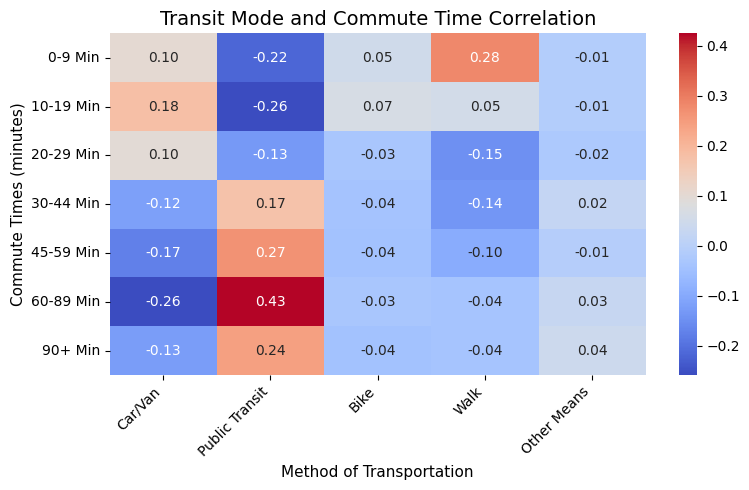

In [ ]:
# Identify transit columns
transit_columns = [
    '% of workers traveling by car, truck, or van',
    '% of workers traveling by public transportation',
    '% of workers traveling by bicycle',
    '% of workers traveling by walking',
    '% of workers traveling by other means']

# Identify time columns
time_columns = [
    '% of workers with commute of 0 to 9 minutes',
    '% of workers with commute of 10 to 19 minutes',
    '% of workers with commute of 20 to 29 minutes',
    '% of workers with commute of 30 to 44 minutes',
    '% of workers with commute of 45 to 59 minutes',
    '% of workers with commute of 60 to 89 minutes',
    '% of workers with commute of 90 or more minutes']

# Filter the DataFrame to include only these columns
correlation_df = transport_time_df[transit_columns + time_columns]

# Calculate correlations
correlations = correlation_df.corr()

# Create heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(
    correlations.loc[time_columns, transit_columns],
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    xticklabels=['Car/Van', 'Public Transit', 'Bike', 'Walk', 'Other Means'],
    yticklabels=['0-9 Min', '10-19 Min', '20-29 Min', '30-44 Min', '45-59 Min', '60-89 Min', '90+ Min'])

# Add title and axis labels, adjust axis
plt.title('Transit Mode and Commute Time Correlation', fontsize=14)
plt.xlabel('Method of Transportation', fontsize=11)
plt.ylabel('Commute Times (minutes)', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

***
## Conclusions
* In conclusion, cars remain the most common and effective method of transportation for the majority of americans, while public transit correlates to longer commutes. Some limitations I have were the inability to break these down by region. I would have liked to analyze transit times in Urban vs Rural areas as well as state by state breakdowns or conmparisons with other countries.


---
---